# Image Classification ML Assignment 

The goal of this assignment is to learn fundamentals of machine learning and image analysis. You will analyze images from Happy Whale, an organization that tracks whales globally, and modify a classifier for these images. 

Part 1: Walk through (Due Feb 27)
- In class, we will walk through the provided code
- This script has several functions that are written for you. For part 1, please do NOT modify any code unless it specifies to change it.
- Answer the questions as you go through the code

Part 2: Make modifications (Due Feb 27)
- Change model parameters or other model aspects at least 3 times 
- Describe what happened when you made these changes

Part 3: Create a team, get inspired and try a new approach to your model (Due March 6)
- Have a group meeting and record your meeting with audio or video (you can record with zoom!)
    - Start by discussing part 2 of the assignment:
        - What approaches you each took to change the ML model in part 2
        - What are similarities and differences between your approaches 
        - What types of changes improved model performance
        - What types of changes made model performance worse
        - Based on the whole group's work, what would y'all want to do next in terms of model optimization?
    - Next, look at code and approaches from the [Happy Whales competition leaderboard](https://www.kaggle.com/competitions/happy-whale-and-dolphin/leaderboard).
        - Is there any strategy that someone used that you could implement? 
            - Ex: learning rate value, # epochs, transformation strategy, or more complex changes to the models
        - Are there strategies that you are interested in learning about?
    - Lastly, make a plan for 1 more round of model optimization
        - Assign each member something to attempt for training the model. Use your cumulative experience to decide the most important things to test. 
        - Group members can make as small as changing the value for a parameter or as big as changing the model.
- Have each member complete their test
- Share results with each other
- Write a 1-3 paragraph summary on your group's attempts and recommendations moving forward
- For Part 3: Turn in the audio/video recording of the group meeting, each member's code (uploaded to their original git repo), and the team's 1-3 paragraph summary over canvas.

### Your choices on data
You can chose between 3 datasets for this assignment. This jupyter notebook is set up using the Species dataset. If you change the dataset, you will need to change the number of classes parameter for the model.
- Species = you will classify images by species (gray, killer, beluga, humpback, false killer, and common dolphin)
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
- Species_all = you will classify images by species (minke, gray, killer, beluga, humpback, false killer, and bottlenose and common dolphin). There are a high number of images for bottlenose dolphins and minke whales which leads to this dataset being quite large. Due to the size of the dataset, it has a longer training time than the "Species" dataset.
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species_all
  - Num classes: 8
- Individuals = you will classify images by individuals. This is a much more challenging classification task because you have different individuals from different species. However, this was the original goal of the Happy Whale competition, so try challenging yourself to this important task!
  - File path: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/individuals
  - Num classes: 110

You are NOT graded by the success of your model, so you are free to train the model on whichever dataset is more interesting to you. However, **everyone on your team for part 3 should be using the same dataset**.

### Part 1

In [1]:
## Importing packages - Please DO NOT alter this box ##
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.nn import functional as F
import torch.optim as optim
from torch.utils.data.sampler import WeightedRandomSampler
torch.manual_seed(0)

from captum.attr import IntegratedGradients
from captum.attr import DeepLift
from captum.attr import NoiseTunnel
from captum.attr import visualization as viz

import torchvision
from torchvision import datasets, transforms
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter()

import os
import imageio
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm
from scipy.ndimage import binary_erosion
import pandas as pd
from sklearn.metrics import confusion_matrix
import seaborn as sns

import wandb #comment this out if you are not using weights and biases
import random #comment this out if you are not using weights and biases

# Set device to cuda if it's available otherwise default to "cpu"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

### Loading in the dataset

By default, this will load in the species dataset, this is the smallest dataset (i.e., it will be relatively fast to train) and has a simple goal (i.e., you will be able to create an accurate model). If you want a challenge, I highly encourage you to try the Species_all (a dataset with 2 additional species) or the individual dataset (a dataset where whales are characterized by individual rather than species).

In [2]:
images = "/projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species"

In [3]:
# We must turn our images into tensors, resize, and normalize them 
# We can also add additional transformations to images 
transform = transforms.Compose([transforms.ToTensor(), 
                                #We will start with a model called Resnet18 that is optimized for 224x224 images
                                #It is set to a very SMALL size initially so the model will train fast in class
                                transforms.Resize([32,32]),
                                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences)
                               ])
all_images = datasets.ImageFolder(images, transform)
print(all_images)

Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


<font color='magenta'>What is the purpose(s) of transforming image data? (2 pts)

<font color='magenta'>The purpose of transforming image data is to prepare raw images for use in a neural network. First, images are converted into tensors so they can be processed by PyTorch. Second, images are resized so that all inputs have the same dimensions, which is required by the model. Third, images are normalized so that pixel values are centered and scaled, which improves training stability and convergence. These transformations ensure the data is compatible with ResNet and allows the model to learn more effectively.

<font color='green'>The below code completes the image transformations as coded in the above box.

In [4]:
all_images = datasets.ImageFolder(images, transform )
print(len(all_images))
print(all_images)

2794
Dataset ImageFolder
    Number of datapoints: 2794
    Root location: /projects/bgmp/shared/Bi625/ML_Assignment/Datasets/Whale_species/species
    StandardTransform
Transform: Compose(
               ToTensor()
               Resize(size=[32, 32], interpolation=bilinear, max_size=None, antialias=True)
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )


Our classification labels will be converted to indices, we can determine which indices is which label using the below code

In [5]:
print(all_images.class_to_idx)

{'beluga': 0, 'common_dolphin': 1, 'false_killer_whale': 2, 'fin_whale': 3, 'gray_whale': 4, 'humpback_whale': 5}


<font color='green'>The below function is used to randomly select dataset images to evaluate how the transformations altered the images.

In [6]:
def show_random_dataset_image(dataset):
    idx = np.random.randint(0, len(dataset))    # take a random sample
    img, mask = dataset[idx]                    # get the image and the nuclei masks
    f, axarr = plt.subplots(1, 2)               # make two plots on one figure
    axarr[0].imshow(img[0], cmap="viridis")                     # show the image, cmap is the color map that the image is being shown in
    #axarr[1].imshow(mask[0])                    # show the masks
    _ = [ax.axis('off') for ax in axarr]        # remove the axes
    print('Image size is %s' % {img[0].shape})
    print(img.shape)
    plt.show()

Image size is {torch.Size([32, 32])}
torch.Size([3, 32, 32])


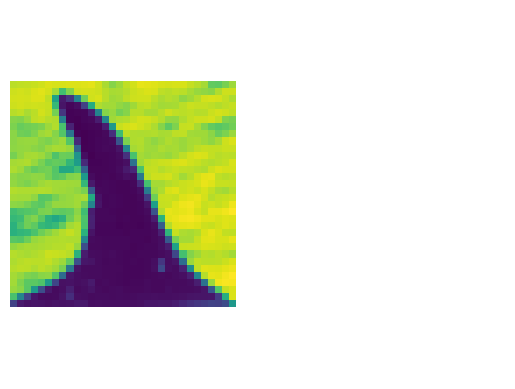

In [7]:
show_random_dataset_image(all_images)

<font color='magenta'>What is the difference between image size and torch image size? (2 pts)

<font color='magenta'>Image size refers to the height and width of an image in pixels, usually in H×W×C format, while torch image size refers to the tensor shape used by PyTorch, which is organized as C×H×W for efficient computation.

<font color='magenta'>Add a new transformation to the training data. After your first run of this model during class time, resize the image to 224x224 pixels. (2 pts)

Image size is {torch.Size([224, 224])}
torch.Size([3, 224, 224])


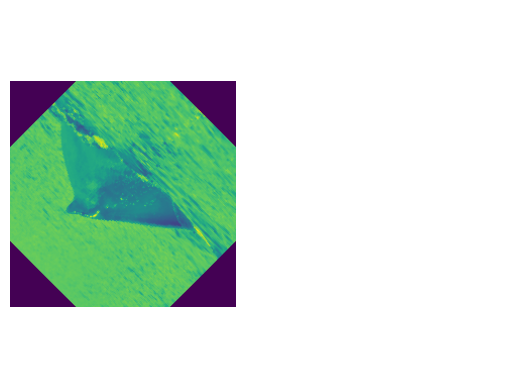

In [8]:
## ADD YOUR TRANSFORMATION HERE
transform = transforms.Compose([
            transforms.Resize([224,224]), # Resize the image as our model is optimized for 224x224 pixels
            transforms.ToTensor(),
            #adding a roation transformation
            transforms.RandomRotation(degrees=(90, 180)),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]) # Normalize the data, these are the values that ResNet suggests based on their training data (natural scences))

all_images = datasets.ImageFolder(images, transform )
show_random_dataset_image(all_images)

<font color='magenta'>How did your transformation impact the images? (1 pt)

<font color='magenta'>It made it clearer, higher resolution and rotated.

### Creating datasets used in training and testing

After loading in the data, we separate the data into training, validation, and testing datasets. The training data is inputted into the model during the training phase, and the model's predictions from this data is used to modulate the weights of the model. The validation data is used while the model trains, but the model is in a evaluation rather than training mode. The validation data gives us a real time view on how accurately the model is predicting our labels. The testing data is used after the model has completed training and tells us how successful our model will be with a novel dataset.

Once creating these 3 datasets, we prepare dataloaders which are used to load the images into our models. These images are loaded in batches into the model (a parameter called batch size). Because our dataset is imbalanced, we use a weighted random sampler to select images for our batches in the dataloader. Therefore to create our dataloader, we start by creating a function to get weights, calculating weights, initiating our weighted random sampler, and then creating our dataloaders.

<font color='green'>The below code eastablishes the data split between training, validation, and testing.

In [9]:
train_size = int(0.7 * len(all_images))
val_size = int(0.15 * len(all_images))
test_size = len(all_images) - (train_size + val_size)
print(train_size, val_size, test_size)
assert train_size + val_size + test_size == len(all_images)

1955 419 420


In [10]:
train_set, val_set, test_set = torch.utils.data.random_split(all_images, [train_size, val_size, test_size])

<font color='green'>The below function is used to get weights for the image classes.

In [11]:
def _get_weights(subset,full_dataset):
    ys = np.array([y for _, y in subset])
    counts = np.bincount(ys)
    label_weights = 1.0 / counts
    weights = label_weights[ys]

    print("Number of images per class:")
    for c, n, w in zip(full_dataset.classes, counts, label_weights):
        print(f"\t{c}:\tn={n}\tweight={w}")
        
    return weights

In [12]:
train_weights = _get_weights(train_set,all_images)
train_sampler = WeightedRandomSampler(train_weights, len(train_weights))

Number of images per class:
	beluga:	n=454	weight=0.0022026431718061676
	common_dolphin:	n=49	weight=0.02040816326530612
	false_killer_whale:	n=718	weight=0.001392757660167131
	fin_whale:	n=120	weight=0.008333333333333333
	gray_whale:	n=47	weight=0.02127659574468085
	humpback_whale:	n=567	weight=0.001763668430335097


<font color='magenta'>What is the impact of the class weight on how data is loaded into the model? What does it mean if a class has a low vs high weight? (2 pts)

<details>
  <summary>Hint</summary>
  
Check out this resource: https://towardsdatascience.com/demystifying-pytorchs-weightedrandomsampler-by-example-a68aceccb452 


<font color='magenta'>Class weights change the probability that samples from each class are selected into training batches. A higher weight means the class has fewer examples and will be sampled more often, increasing its representation in batches. A lower weight means the class has many examples and will be sampled less often to prevent it from dominating training. In our dataset, rare classes like gray_whale and common_dolphin get high weights, while common classes like false_killer_whale get low weights.

In [13]:
train_loader = DataLoader(train_set, batch_size=48, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=48, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=48, drop_last=True, shuffle=True)

### Picking hyperparameters

We can set a few hyperparameters that we decide and can tune. These include:

- Learning rate = how much to update our model's parameters at each batch/epoch
- batch size = the number of data samples to pass through the network before updating it
    - If you change the batchsize below, make sure you ALSO change it in the commands above for the DataLoader
- Number of epochs = # of times to iterate over the dataset in model training

In [13]:
learning_rate=1e-3
batchsize=48
epochs=5

<font color='magenta'>How would model training be impacted if we decreased our learning rate? What about if we increased it? (2 pts)

<font color='magenta'>Decreasing the learning rate makes the model update its weights more slowly, which leads to more stable and precise learning but requires more epochs to converge. Increasing the learning rate makes weight updates larger, which can speed up training initially but may cause instability, overshooting of the optimal solution, or failure to converge. Therefore, choosing an appropriate learning rate is important for balancing speed and stability.

### Training our model

For part 1, we are going to use the model ResNet18. This is a published model for imaging data. Resnet18 is built from 4 residual blocks with two convolutional layers (Conv2d). Each convolutional layer is followed by a batch normalization step (BatchNorm2D) and a ReLU activation layer (ReLU). There is also a shortcut connection which adds input to output and allows the network to learn residual mapping.

I provided the complete code for the ResNet18 model. In the future, if you want to use resnet18, you can load it simply by running `resnet18_model = torchvision.models.resnet18(weights = False, progress  = True, num_classes=XXX)`. We will look at the full code for the model so you can see how this model was created.  

<font color='green'>The below code builds the residual blocks that ResNet18 uses in the model.

In [14]:
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    # Initializing method for the basic block (It's OOP!)
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

<font color='green'>The below code builds and initializes the ResNet18 model.

In [15]:
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of filters/channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)
print(model)

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=

<font color='green'>The below code eastablishes the loss function and optimizer used in training the model.

In [16]:
#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

<font color='green'>The below functions are used to train, evaluate, and test the Machine Learning model.

In [17]:
wandb.login()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/manasvil/.netrc.
wandb: Currently logged in as: manasvil (manasvil-university-of-oregon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [18]:
wandb.init(
    project="BGMP_HappyWhale",
    name="manasvil-university-of-oregon", ### Update with your name!
    config={"learning rate":0.001,
        "architecture": "CNN",
        "dataset": "Species",
        "epochs":5}
)

num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    batch=0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

Epoch [1/5] | Batch #1 | Batch Accuracy 18.75%
Epoch [1/5] | Batch #2 | Batch Accuracy 15.62%
Epoch [1/5] | Batch #3 | Batch Accuracy 23.61%
Epoch [1/5] | Batch #4 | Batch Accuracy 27.08%
Epoch [1/5] | Batch #5 | Batch Accuracy 32.08%
Epoch [1/5] | Batch #6 | Batch Accuracy 34.72%
Epoch [1/5] | Batch #7 | Batch Accuracy 36.90%
Epoch [1/5] | Batch #8 | Batch Accuracy 37.76%
Epoch [1/5] | Batch #9 | Batch Accuracy 39.58%
Epoch [1/5] | Batch #10 | Batch Accuracy 40.42%
Epoch [1/5] | Batch #11 | Batch Accuracy 42.23%
Epoch [1/5] | Batch #12 | Batch Accuracy 46.01%
Epoch [1/5] | Batch #13 | Batch Accuracy 46.31%
Epoch [1/5] | Batch #14 | Batch Accuracy 47.32%
Epoch [1/5] | Batch #15 | Batch Accuracy 48.19%
Epoch [1/5] | Batch #16 | Batch Accuracy 49.35%
Epoch [1/5] | Batch #17 | Batch Accuracy 50.12%
Epoch [1/5] | Batch #18 | Batch Accuracy 50.12%
Epoch [1/5] | Batch #19 | Batch Accuracy 51.21%
Epoch [1/5] | Batch #20 | Batch Accuracy 52.08%
Epoch [1/5] | Batch #21 | Batch Accuracy 52.28%
E

train_loss,█▅▃▂▁
validation_accuracy,▁▅▂██
validation_loss,█▃▆▁▁
train_loss,0.43046
validation_accuracy,78.90625
validation_loss,0.51305


#### For our class training, run the below model and consider the success of the model training. 

<font color='magenta'>What is your starting accuracy and final accuracy? What happened to the model to change the accuracy from epoch 1 to 5? (2 pts)

<font color='magenta'>The validation accuracy increased from about 57.6% at Epoch 1 to about 78.9% at Epoch 5. This improvement occurred because the model adjusted its weights over multiple epochs and learned better features for distinguishing whale species.

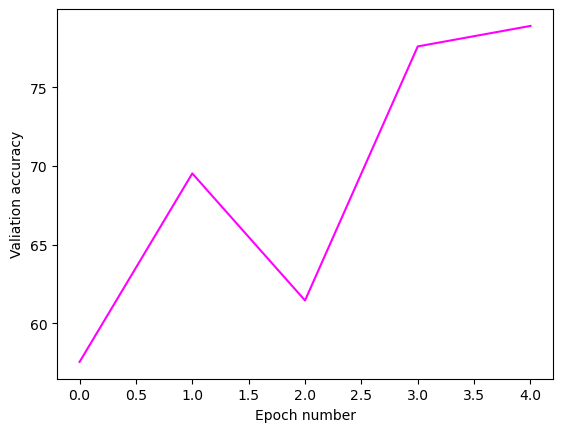

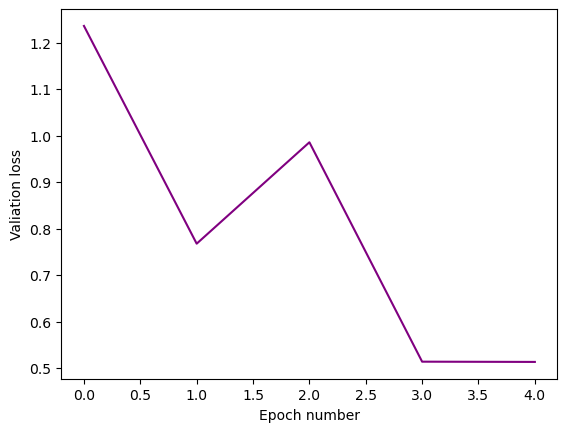

In [19]:
plt.plot(range(num_epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(num_epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show() 

<font color='green'>After running the model and calculating the overall accuracy, we can examine the data via a confusion matrix which highlights the accuracy by class.

[5 2 0 2 0 2 5 2 3 0 5 3 5 5 2 5 3 2 5 2 2 5 2 5 5 2 5 2 5 5 0 0 0 4 1 2 2
 2 5 5 5 3 2 5 2 3 2 5 2 2 0 5 2 3 3 5 2 0 2 2 0 0 0 2 0 0 5 2 0 2 5 5 3 2
 5 0 0 5 5 2 4 5 5 2 2 2 0 5 5 0 2 0 0 2 0 2 2 5 2 5 5 4 0 0 2 0 2 0 2 0 5
 0 3 0 0 0 2 2 5 1 2 5 2 3 4 0 5 2 3 0 2 5 0 5 0 0 0 5 5 5 2 5 0 2 5 0 3 2
 5 2 5 2 2 2 0 2 5 0 0 0 0 5 0 2 5 2 5 2 0 5 2 2 2 5 2 5 5 5 5 5 5 0 3 5 0
 3 5 5 4 2 5 2 5 2 2 2 2 5 2 2 2 5 2 2 5 2 2 2 0 1 5 5 5 0 2 5 5 0 2 2 2 2
 2 2 5 2 2 5 1 2 2 2 3 0 0 5 5 4 0 5 2 2 5 0 4 5 4 5 2 0 2 2 5 2 5 0 5 0 2
 3 2 5 0 0 2 5 0 2 0 2 0 1 0 2 2 5 2 5 2 3 2 5 2 5 5 0 2 2 2 4 5 5 5 5 0 0
 0 5 2 0 0 5 2 3 2 0 3 5 2 5 0 2 4 2 2 2 2 2 3 0 1 2 0 2 5 2 5 5 2 5 3 0 5
 3 2 2 5 2 0 3 5 2 0 0 0 1 1 2 5 2 2 2 0 5 2 3 2 2 0 0 2 0 3 2 2 2 2 4 5 2
 2 0 2 5 0 2 0 2 2 2 0 2 2 5 0 0 0 2 2 2 5 0 2 2 3 2 0 0 0 0 2 2 0 5 0 4 0
 3 2 5 2 5 2 2 5 5 0 2 2 2]


/tmp/ipykernel_2776187/2764316866.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


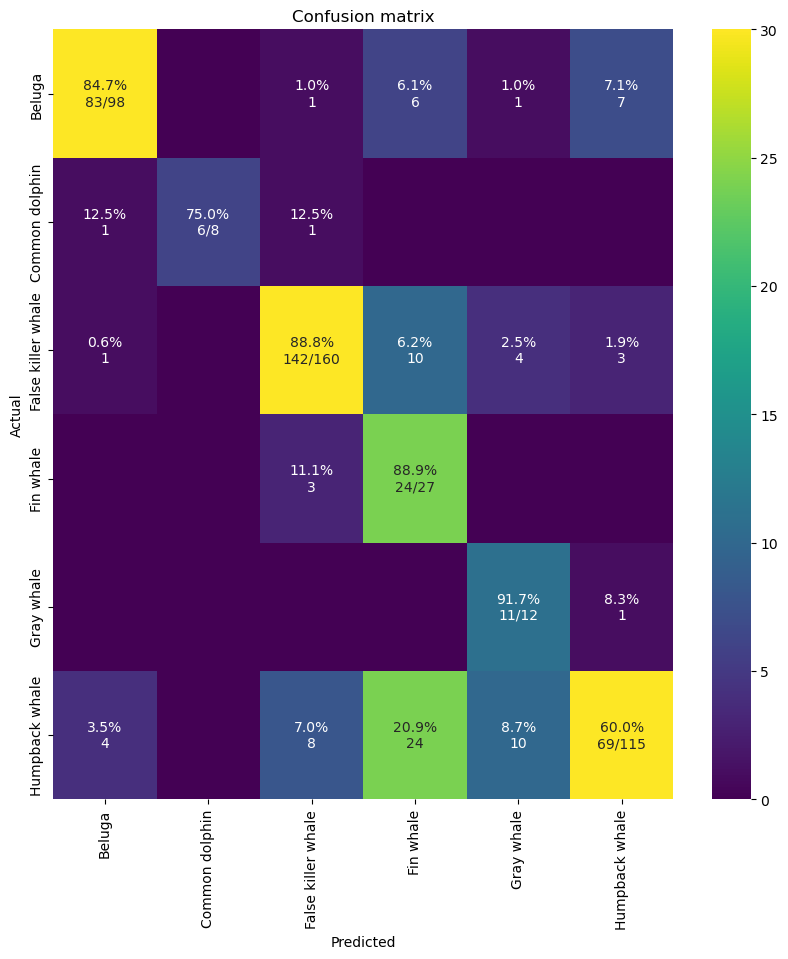

In [20]:
# predict the test dataset
def predict(model, dataset):
    dataset_prediction = []
    dataset_groundtruth = []
    model = model
    with torch.no_grad():
        for x, y_true in dataset:
            inp = x[None]
            y_pred = model(inp)
            dataset_prediction.append(y_pred.argmax().cpu().numpy())
            dataset_groundtruth.append(y_true)
    
    return np.array(dataset_prediction), np.array(dataset_groundtruth)
            
    # create seaborn heatmap with required labels
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
    ax.set_title(title)

# Plot confusion matrix 
# orginally from Runqi Yang; 
# see https://gist.github.com/hitvoice/36cf44689065ca9b927431546381a3f7
def cm_analysis(y_true, y_pred, title, figsize=(10,10)):
    """
    Generate matrix plot of confusion matrix with pretty annotations.
    The plot image is saved to disk.
    args: 
      y_true:    true label of the data, with shape (nsamples,)
      y_pred:    prediction of the data, with shape (nsamples,)
      filename:  filename of figure file to save
      labels:    string array, name the order of class labels in the confusion matrix.
                 use `clf.classes_` if using scikit-learn models.
                 with shape (nclass,).
      ymap:      dict: any -> string, length == nclass.
                 if not None, map the labels & ys to more understandable strings.
                 Caution: original y_true, y_pred and labels must align.
      figsize:   the size of the figure plotted.
    """
    labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale']
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
                              
    x_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for x-axis
    y_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for y-axis
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels, cmap = "viridis")
    ax.set_title(title)

## This plot only contains the test set of data
## The test set of data has not been seen by the model yet
y_pred, y_true = predict(model, test_set)

print(y_true)
cm_analysis(y_true, y_pred, "Confusion matrix")

### What features did the model use to make decisions?

Based on the confusion matrices and validation loss, it is clear that the model is learning. To determine the features that are involved in decision making, there are a few possible approaches. One options is shown below, integrated gradients. 

#### Understanding feature importance using Integrated Gradients

<font color='green'>Integrated gradients is an attribution method. Attribution methods score the input data based on the prediction that the model makes using scores for each feature. The gradient is the signal that tells the network how much to increase or decrease a certain weight in the network during backpropogation. These gradients are overlaid onto the images to showcase the regions on the images that influence the weights.

Run the below code. 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.45754117..0.9568449].


Annotated whale species 5
Predicted whale species 3


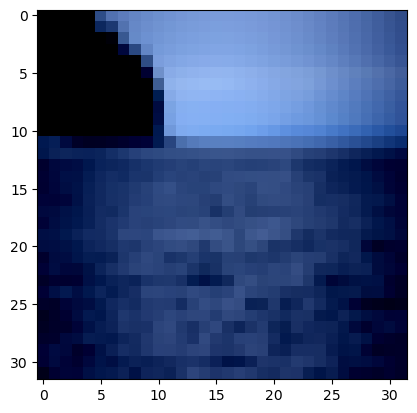

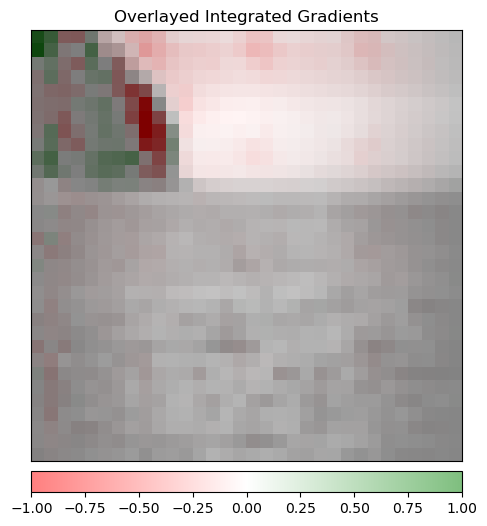

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.22673559..1.27586].


Annotated whale species 3
Predicted whale species 3


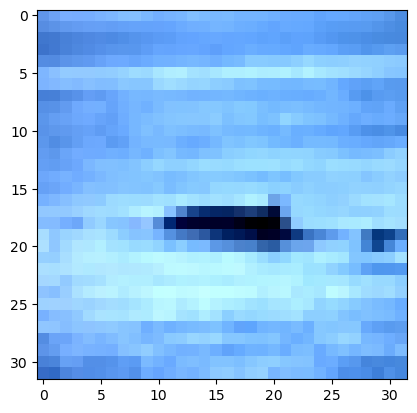

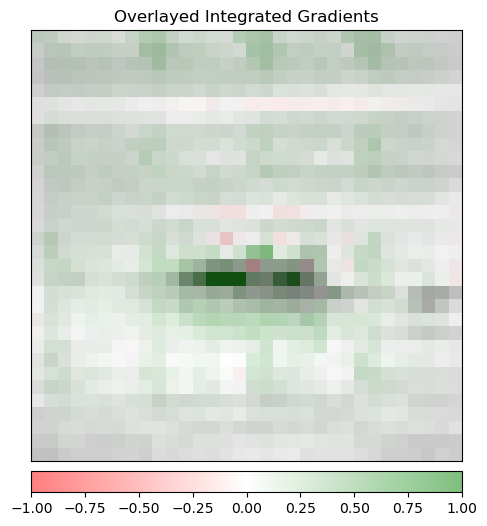

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49542361..1.7913442].


Annotated whale species 2
Predicted whale species 2


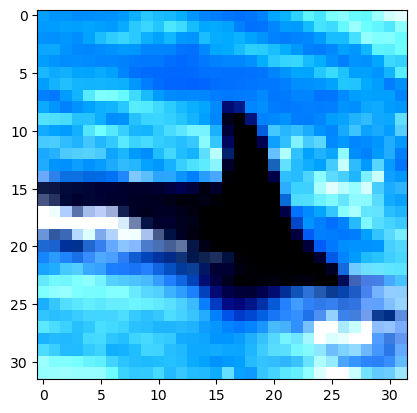

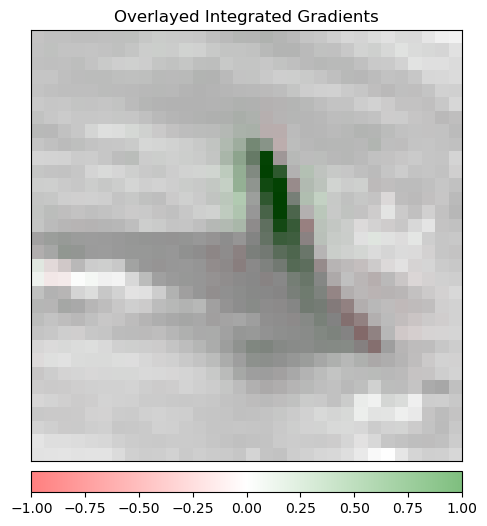

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.18162197..1.4053097].


Annotated whale species 0
Predicted whale species 0


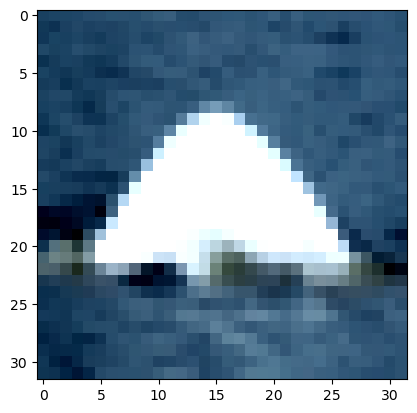

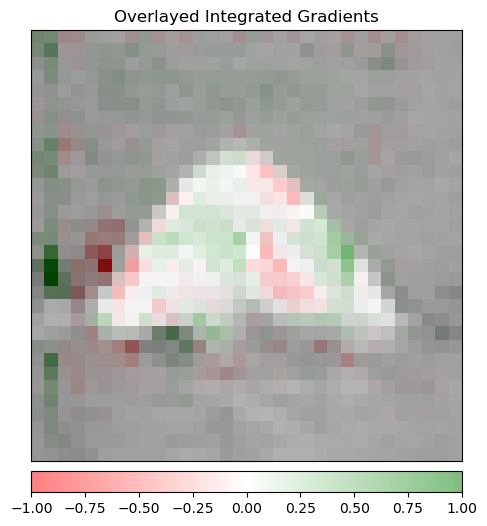

In [21]:
def visualize_ig(idx, 
                 _train_dataset=train_set, 
                 _test_dataset=test_set):
        
    # Get corresponding input and target tensors:
    input_tensor = _test_dataset[idx][0].unsqueeze(0)
    input_tensor.requires_grad = True
    target = _test_dataset[idx][1]
    
    # We will use the IntegratedGradients algorithm:
    algorithm = IntegratedGradients(model)
    
    # First we clear the gradients from the model:
    model.zero_grad()
    
    # Run attribution:
    attr_ig, delta = algorithm.attribute(input_tensor,
                                          target=target,
                                          baselines=input_tensor * 0,
                                          return_convergence_delta=True
                                        )
    
    # Integrated Gradients:
    attr_ig = np.transpose(attr_ig[0].cpu().detach().numpy(), (1, 2, 0))
    
    # Original image:
    original_image = np.transpose((_test_dataset[idx][0].detach().numpy() * 0.5) + 0.5, (1, 2, 0))
    
    print("Annotated whale species", test_true[idx])
    plt.imshow(original_image)
    
    
    print("Predicted whale species", test_pred[idx])


    # This visualises the attribution of labels to 
    viz.visualize_image_attr(attr_ig, 
                             original_image, 
                             method="blended_heat_map",
                             sign="all",
                             show_colorbar=True, 
                             title="Overlayed Integrated Gradients")

test_pred, test_true = predict(model, test_set)

visualize_ig(0)
visualize_ig(8)
visualize_ig(20)
visualize_ig(32)

<font color='magenta'>Does the integrated gradient show what types of features the model used to classify the images? Do you notice any potential problems? (2 pts)

<font color='magenta'>Integrated gradients shows that the model mainly uses whale shape and contrast, but also sometimes relies on background features, which could limit generalization(especially in the fourth image).

## Part 2 

Now that you have a sense for how to train a machine learning model, your task is to improve the success of our classification model.

**In three separate training events, make one (or more) modifications to the model training process, re-train the model, and report out your changes and whether they increased model accuracy. Why did you chose your particular change (curiousity, hypothesis, ect.)? Do you have ideas why your modifications were/were not successful?**

Types of changes that you can make include:
- [Using the pre-trained weights for ResNet18 (transfer learning)](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) 
- Changing hyperparameters (learning rate, batch size)
- [Changing transformation approach](https://docs.pytorch.org/vision/0.11/auto_examples/plot_transforms.html#sphx-glr-auto-examples-plot-transforms-py)
- [Changing the optimizer](https://docs.pytorch.org/docs/stable/optim.html)
- [Changing the model to a different pre-made model architecture](https://docs.pytorch.org/vision/main/models.html)
- Modifying the ResNet18 model
- Coming up with a whole new model!

If you decide to change any lines of code that are not in the below box, please add them to the box (DO NOT MODIFY ANY CODE ABOVE THIS MARKDOWN BOX - IT MAY BREAK PART 1). 

If your changes are ambitious, the code may take hours to run. If this is the case, please consider turning this notebook into a python script and running it via sBATCH. 

**Please note, you will NOT be graded by the success of your classifiers! It is okay if you are unable to improve the accuracy of the classifier**

#### Your Model 1 (10 pts)

<font color='magenta'>Describe your changes to the model training process (either changing something about the model, a hyperparameter, how data was inputted into the model, or another aspect) and why you selected those changes.

In experiment 1, I decreased the learning rate to 3e-4 and increased epochs to 8. I chose this because a smaller learning rate often stabilizes training and longer training can help the model converge more fully

In [25]:
batchsize = 48
learning_rate=3e-4
epochs=8

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [26]:
## Model
#########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of filters/channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_loss,▁
validation_accuracy,▁
validation_loss,▁
train_loss,0.86132
validation_accuracy,60.67708
validation_loss,0.98634


Epoch [1/8] | Batch #1 | Batch Accuracy 14.58%
Epoch [1/8] | Batch #2 | Batch Accuracy 28.12%
Epoch [1/8] | Batch #3 | Batch Accuracy 37.50%
Epoch [1/8] | Batch #4 | Batch Accuracy 39.58%
Epoch [1/8] | Batch #5 | Batch Accuracy 42.50%
Epoch [1/8] | Batch #6 | Batch Accuracy 45.83%
Epoch [1/8] | Batch #7 | Batch Accuracy 48.21%
Epoch [1/8] | Batch #8 | Batch Accuracy 48.18%
Epoch [1/8] | Batch #9 | Batch Accuracy 50.23%
Epoch [1/8] | Batch #10 | Batch Accuracy 50.83%
Epoch [1/8] | Batch #11 | Batch Accuracy 52.27%
Epoch [1/8] | Batch #12 | Batch Accuracy 53.47%
Epoch [1/8] | Batch #13 | Batch Accuracy 54.17%
Epoch [1/8] | Batch #14 | Batch Accuracy 56.25%
Epoch [1/8] | Batch #15 | Batch Accuracy 56.81%
Epoch [1/8] | Batch #16 | Batch Accuracy 58.33%
Epoch [1/8] | Batch #17 | Batch Accuracy 59.44%
Epoch [1/8] | Batch #18 | Batch Accuracy 60.42%
Epoch [1/8] | Batch #19 | Batch Accuracy 61.62%
Epoch [1/8] | Batch #20 | Batch Accuracy 62.40%
Epoch [1/8] | Batch #21 | Batch Accuracy 62.40%
E

train_loss,█▄▃▂▂▁▁▁
validation_accuracy,▁▅▆▆█▃▅▅
validation_loss,█▅▂▂▁▇▄▆
train_loss,0.11091
validation_accuracy,74.47917
validation_loss,0.82931


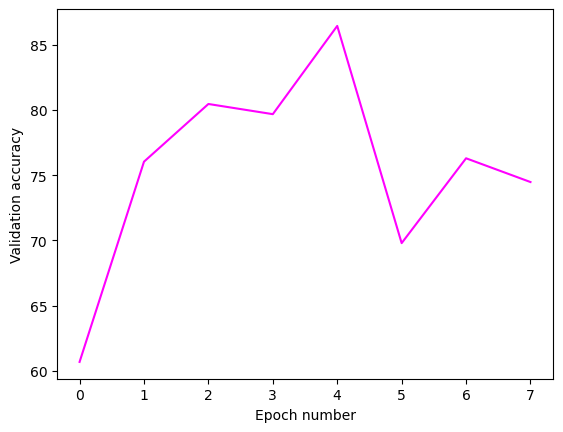

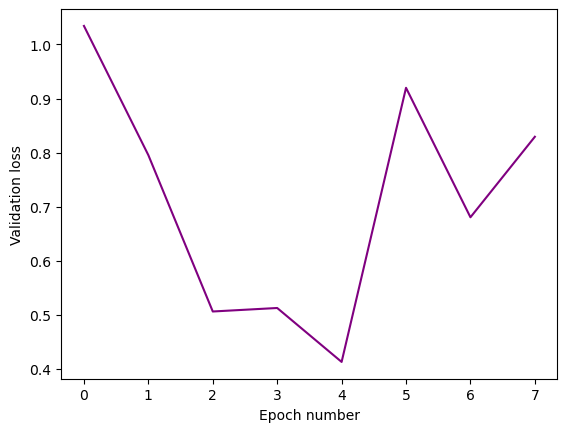

/tmp/ipykernel_2776187/2764316866.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


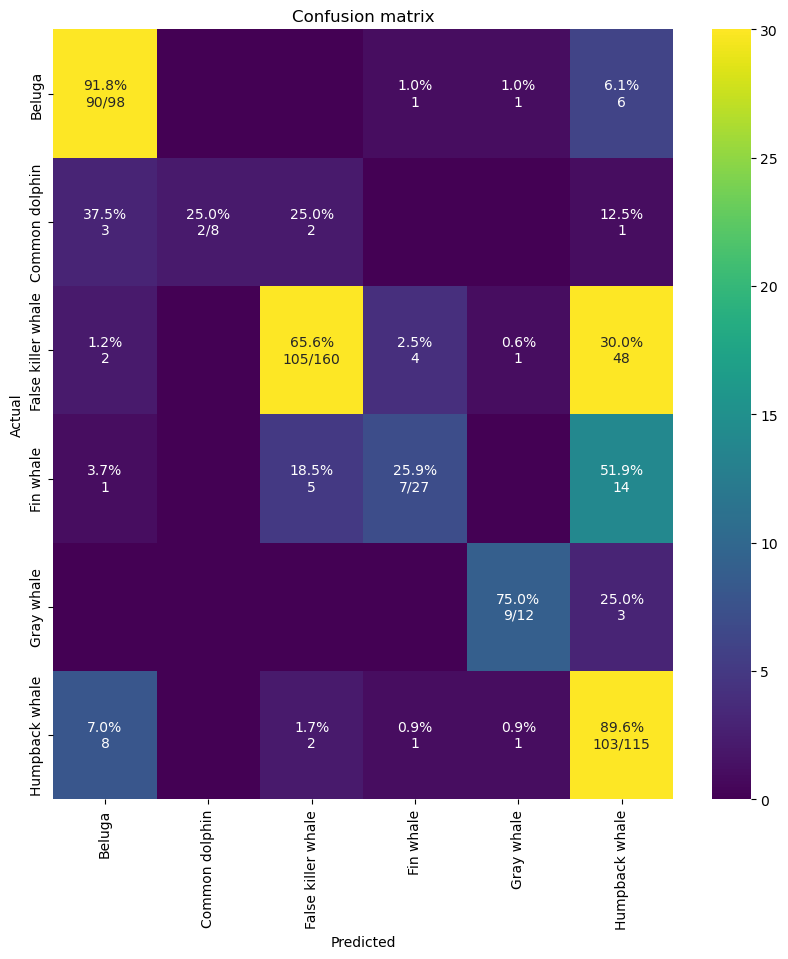

In [27]:
wandb.init(
    project="BGMP_HappyWhale",
    name="manasvil-university-of-oregon", ##update this with your name
    config={"learning rate":.01, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 3, "batch_size":48}  # possibly update
) 

batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

plt.plot(range(len(val_acc_list)), val_acc_list, color="magenta")
plt.xlabel("Epoch number")
plt.ylabel("Validation accuracy")
plt.show()

plt.plot(range(len(val_losses)), val_losses, color="purple")
plt.xlabel("Epoch number")
plt.ylabel("Validation loss")
plt.show()

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

<font color='magenta'>Were your changes successful? Do you have ideas why your changes were successful or not? 

In this experiment, I decreased the learning rate from 1e-3 to 3e-4 and increased the number of epochs from 5 to 8 to allow the model to learn more gradually and improve convergence. This change was overall successful compared to the baseline, as validation accuracy improved and several classes showed stronger diagonal performance in the confusion matrix. Although accuracy fluctuated in later epochs, the model achieved better overall generalization. The lower learning rate likely allowed more stable weight updates, helping the model learn more refined feature representations, even if training required more epochs to fully stabilize.

#### Your Model 2 (10pts)

<font color='magenta'>Describe your changes to the model training process (either changing something about the model, a hyperparameter, how data was inputted into the model, or another aspect) and why you selected those changes.

Experiment 2 added data augmentation (random flips, small rotations, and color jitter) to the training transform only. I chose this to reduce overfitting and encourage the model to learn whale-specific features rather than background cues.

In [36]:
# Define training transformations with data augmentation
train_transform = transforms.Compose([
    transforms.Resize([32, 32]),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Define validation and test transformations without augmentation
eval_transform = transforms.Compose([
    transforms.Resize([32, 32]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load dataset without transforms for splitting
base_ds = datasets.ImageFolder(images)
n = len(base_ds)

# Define dataset split sizes
train_size = int(0.7 * n)
val_size = int(0.15 * n)
test_size = n - train_size - val_size

# Randomly split dataset indices with fixed seed
generator = torch.Generator().manual_seed(0)
train_idx, val_idx, test_idx = torch.utils.data.random_split(
    range(n), [train_size, val_size, test_size], generator=generator
)

# Reload datasets with appropriate transforms
train_ds = datasets.ImageFolder(images, transform=train_transform)
eval_ds  = datasets.ImageFolder(images, transform=eval_transform)

# Create training, validation, and test subsets
train_set = torch.utils.data.Subset(train_ds, train_idx.indices)
val_set   = torch.utils.data.Subset(eval_ds, val_idx.indices)
test_set  = torch.utils.data.Subset(eval_ds, test_idx.indices)

# Compute class weights for imbalanced training data
def _get_weights_from_subset(subset, full_classes):

    ys = np.array([subset.dataset.targets[i] for i in subset.indices])
    counts = np.bincount(ys, minlength=len(full_classes))
    label_weights = 1.0 / counts
    weights = label_weights[ys]

    print("Number of images per class (train subset):")
    for c, n, w in zip(full_classes, counts, label_weights):
        print(f"\t{c}:\tn={n}\tweight={w}")

    return weights

# Create weighted sampler for balanced training
train_weights = _get_weights_from_subset(train_set, train_ds.classes)
train_sampler = WeightedRandomSampler(train_weights, len(train_weights))

Number of images per class (train subset):
	beluga:	n=465	weight=0.002150537634408602
	common_dolphin:	n=50	weight=0.02
	false_killer_whale:	n=716	weight=0.0013966480446927375
	fin_whale:	n=116	weight=0.008620689655172414
	gray_whale:	n=44	weight=0.022727272727272728
	humpback_whale:	n=564	weight=0.0017730496453900709


In [37]:
batchsize = 32
learning_rate=1e-3
epochs=5

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [38]:
## Model
#########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Epoch [1/5] | Batch #1 | Batch Accuracy 18.75%
Epoch [1/5] | Batch #2 | Batch Accuracy 20.31%
Epoch [1/5] | Batch #3 | Batch Accuracy 25.00%
Epoch [1/5] | Batch #4 | Batch Accuracy 24.22%
Epoch [1/5] | Batch #5 | Batch Accuracy 27.50%
Epoch [1/5] | Batch #6 | Batch Accuracy 29.17%
Epoch [1/5] | Batch #7 | Batch Accuracy 32.14%
Epoch [1/5] | Batch #8 | Batch Accuracy 30.08%
Epoch [1/5] | Batch #9 | Batch Accuracy 31.94%
Epoch [1/5] | Batch #10 | Batch Accuracy 33.12%
Epoch [1/5] | Batch #11 | Batch Accuracy 34.94%
Epoch [1/5] | Batch #12 | Batch Accuracy 35.42%
Epoch [1/5] | Batch #13 | Batch Accuracy 35.82%
Epoch [1/5] | Batch #14 | Batch Accuracy 37.28%
Epoch [1/5] | Batch #15 | Batch Accuracy 37.71%
Epoch [1/5] | Batch #16 | Batch Accuracy 37.11%
Epoch [1/5] | Batch #17 | Batch Accuracy 37.50%
Epoch [1/5] | Batch #18 | Batch Accuracy 38.02%
Epoch [1/5] | Batch #19 | Batch Accuracy 38.98%
Epoch [1/5] | Batch #20 | Batch Accuracy 39.69%
Epoch [1/5] | Batch #21 | Batch Accuracy 40.62%
E

train_loss,█▄▃▂▁
validation_accuracy,▁▅▇██
validation_loss,█▅▃▂▁
train_loss,0.6802
validation_accuracy,72.11538
validation_loss,0.65024


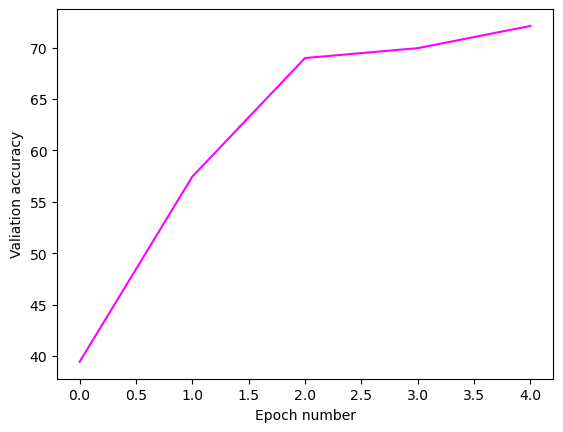

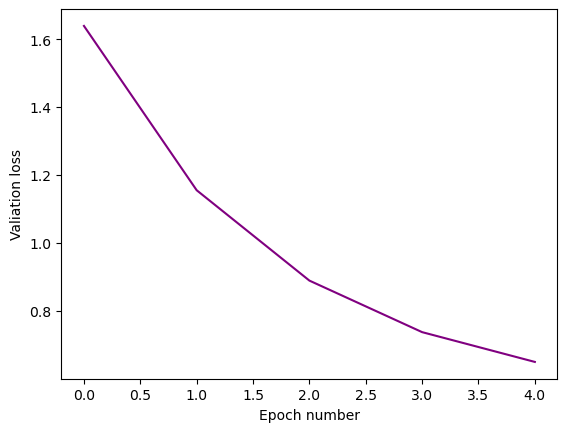

/tmp/ipykernel_3987589/2764316866.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


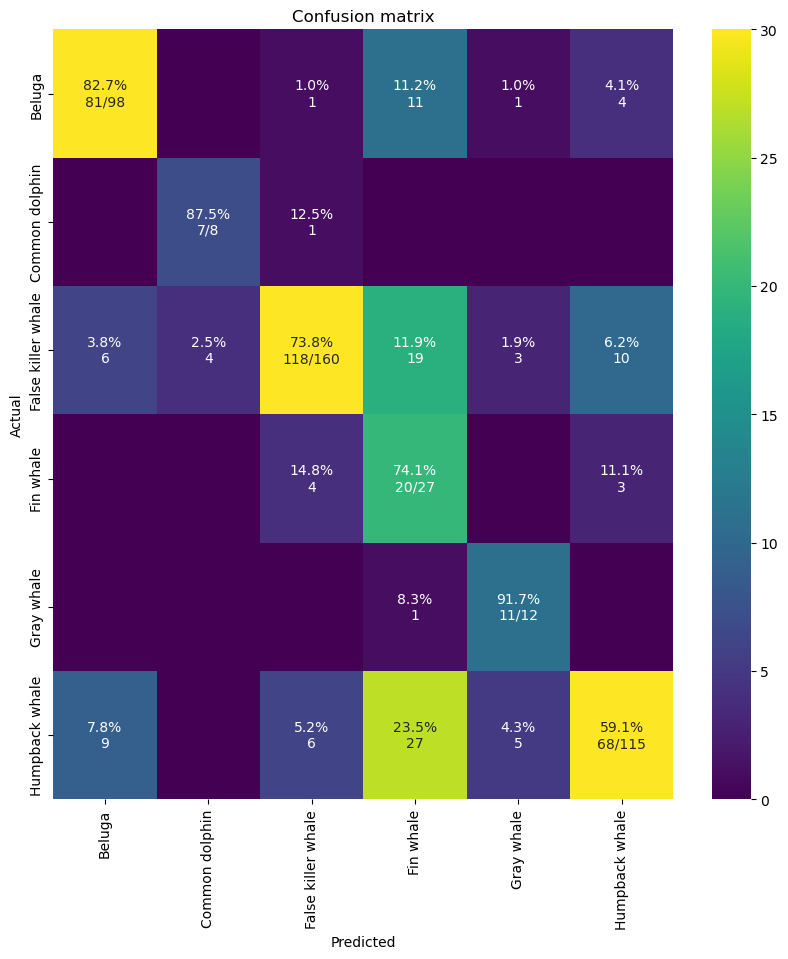

In [39]:
wandb.init(
    project="BGMP_HappyWhale",
    name="manasvil-university-of-oregon", ##update this with your name
    config={"learning rate":.001, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 3, "batch_size":32}  # possibly update
) 

batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

<font color='magenta'>Were your changes successful? Do you have ideas why your changes were successful or not? 

In this experiment, I added data augmentation to the training pipeline, including random flips, rotations, and color jitter. This was done to improve generalization and reduce reliance on background features. The model showed more stable validation loss and improved performance on some difficult classes, such as Humpback whales. However, overall accuracy did not increase substantially, and several species were still frequently misclassified. This suggests that while augmentation helped reduce overfitting, the low image resolution and visual similarity between species still limited performance.

#### Your Model 3 (10 pts)

<font color='magenta'>Describe your changes to the model training process (either changing something about the model, a hyperparameter, how data was inputted into the model, or another aspect) and why you selected those changes.

I changed the optimizer from Adam to SGD with momentum (and weight decay), lowered the learning rate to 5e-3, and increased training to 12 epochs. I chose this because SGD with momentum often gives steadier updates and can generalize better for CNN image classification, and the extra epochs give the model more chances to learn once the learning rate is smaller.

In [40]:
batchsize = 48
learning_rate=5e-3
epochs=12

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [41]:
## Model
#########
## First, we create the basic block that will be used in our residual net
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()
        ## Conv1: convolution layer, batch normalization, ReLU activation
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

        ## Conv2: convolution layer, batch normalization
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        ## Shortcut connection: adds input to output
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    # The forward method calls on each layer
    def forward(self, x):
        ## Conv1: convolution layer, batch normalization, ReLU activation
        out = self.conv1(x) 
        out = self.bn1(out)
        out = self.relu(out)
        ## Conv2: convolution layer, batch normalization
        out = self.conv2(out)
        out = self.bn2(out)
        ## Shortcut connection
        out += self.shortcut(x)
        ## Final activation
        out = self.relu(out)
        return out

############
## Next, we put together these building blocks and create our residual net
class ResNet18(nn.Module):
    # specify the number of classes that we are predicting
    def __init__(self, num_classes=6):
        super(ResNet18, self).__init__()
        # In channels = Num pixels in H + Num pixels in W
        self.in_channels = 64
        
        # First convolution set (convolution, batch norm, relu)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        # Our building blocks
        # The numbers correspond to the matrix shape
        ### We increase the number of channels (i.e., the first number) as we go
        self.layer1 = self._make_layer(BasicBlock, 64, 2, stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, 2, stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, 2, stride=2)
        self.layer4 = self._make_layer(BasicBlock, 512, 2, stride=2)

        # Average pooling 
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        # Final layer that makes the classification
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_channels, out_channels, stride))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        # First convolution set (convolution, batch norm, relu)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        # Our 4 building blocks
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        # Final layer that makes the classification
        out = self.fc(out)
        return out

## Getting our model and transferring it to the GPU
model = ResNet18().to(device)

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-4)

Epoch [1/12] | Batch #1 | Batch Accuracy 12.50%
Epoch [1/12] | Batch #2 | Batch Accuracy 16.67%
Epoch [1/12] | Batch #3 | Batch Accuracy 18.06%
Epoch [1/12] | Batch #4 | Batch Accuracy 21.35%
Epoch [1/12] | Batch #5 | Batch Accuracy 25.42%
Epoch [1/12] | Batch #6 | Batch Accuracy 28.47%
Epoch [1/12] | Batch #7 | Batch Accuracy 29.46%
Epoch [1/12] | Batch #8 | Batch Accuracy 29.69%
Epoch [1/12] | Batch #9 | Batch Accuracy 29.40%
Epoch [1/12] | Batch #10 | Batch Accuracy 30.63%
Epoch [1/12] | Batch #11 | Batch Accuracy 32.77%
Epoch [1/12] | Batch #12 | Batch Accuracy 33.16%
Epoch [1/12] | Batch #13 | Batch Accuracy 33.17%
Epoch [1/12] | Batch #14 | Batch Accuracy 33.48%
Epoch [1/12] | Batch #15 | Batch Accuracy 34.03%
Epoch [1/12] | Batch #16 | Batch Accuracy 35.16%
Epoch [1/12] | Batch #17 | Batch Accuracy 35.29%
Epoch [1/12] | Batch #18 | Batch Accuracy 36.92%
Epoch [1/12] | Batch #19 | Batch Accuracy 38.38%
Epoch [1/12] | Batch #20 | Batch Accuracy 39.38%
Epoch [1/12] | Batch #21 | Ba

train_loss,█▅▄▄▃▃▂▂▂▁▁▁
validation_accuracy,▁▁▄▄▂▅▆▅▆███
validation_loss,▇█▄▅▇▂▅▄▄▂▁▂
train_loss,0.25242
validation_accuracy,84.11458
validation_loss,0.50268


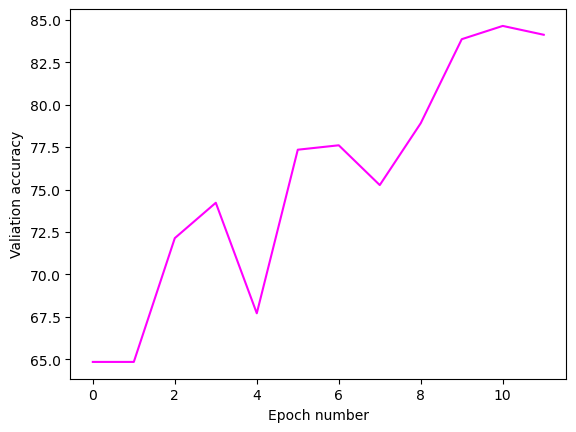

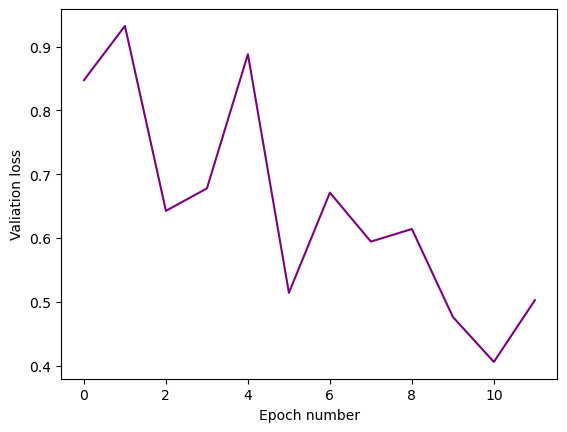

/tmp/ipykernel_3987589/2764316866.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


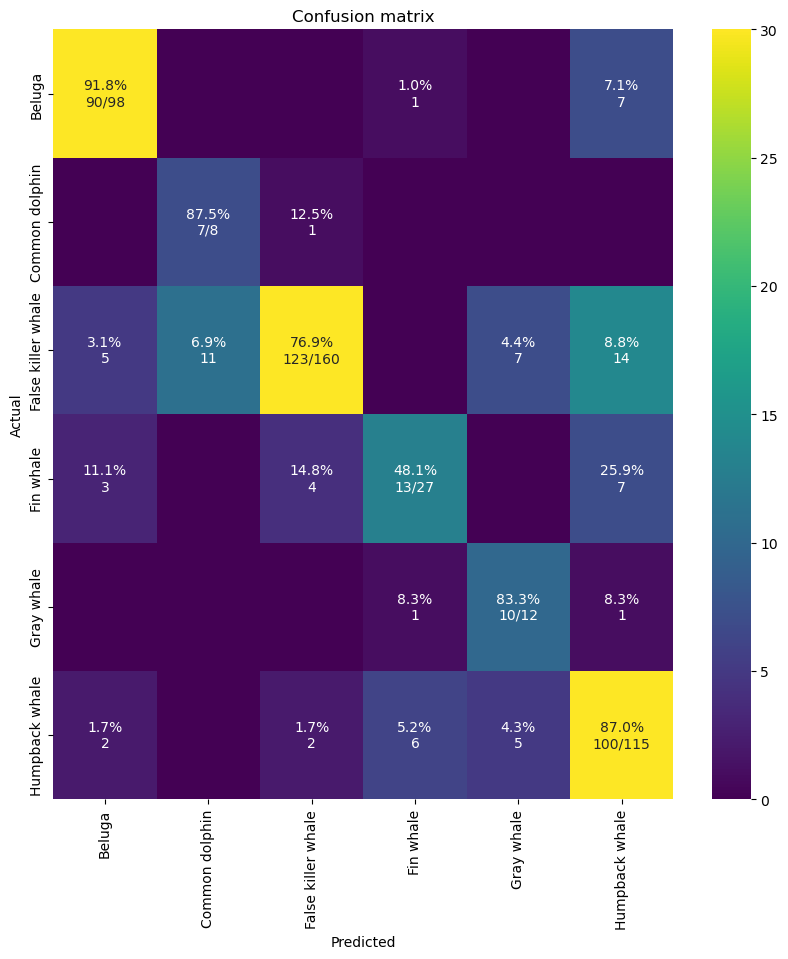

In [42]:
wandb.init(
    project="BGMP_HappyWhale",
    name="manasvil-university-of-oregon_mod3", ##update this with your name
    config={"learning rate":.005, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 15, "batch_size":48}  # possibly update
) 

batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")

<font color='magenta'>Were your changes successful? Do you have ideas why your changes were successful or not? 

Yes, the changes were successful. Validation accuracy increased over training and finished around 84%. I think it helped because the smaller learning rate made updates less jumpy, and momentum helped the model move consistently in a good direction instead of bouncing around. The longer training also let accuracy keep improving instead of stopping early.

<font color='magenta'>Summarize your 3 steps, their success, and what you learned (5 pts)

Experiment 1 (hyperparameters): I lowered the learning rate and increased the number of epochs. This was overall successful compared to the baseline, as validation accuracy improved and the model showed better generalization. However, some classes were still confused, indicating that hyperparameter tuning alone could not fully resolve class overlap. I learned that adjusting learning rate and training duration can improve stability and performance, but it does not completely fix deeper issues like class similarity or imbalance.

Experiment 2 (data input): I added data augmentation during training (flip, small rotation, color jitter) while keeping validation/testing clean. This was somewhat successful because it helped the model handle more variation and improved stability, but it did not fully fix the hardest class mix-ups. I learned that augmentation can help generalization, especially when the dataset is limited or biased.

Experiment 3 (optimizer + training schedule): I switched the optimizer to SGD with momentum (and weight decay), lowered the learning rate to 5e-3, and trained for 12 epochs. This was successful, reaching about 84% validation accuracy. I learned that optimizer choice and training dynamics can matter a lot, and SGD + momentum with a reasonable learning rate can give better generalization than default Adam in this setup.

In [14]:
## Part 3
batchsize = 32
learning_rate = 5e-3
epochs = 11

train_loader = DataLoader(train_set, batch_size=batchsize, drop_last=True, sampler=train_sampler)
val_loader = DataLoader(val_set, batch_size=batchsize, drop_last=True, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batchsize, drop_last=True, shuffle=True)

In [15]:
## Model: Changing the model to a different pre-made model architecture, with pre-trained weights
#########
import torchvision.models as models
from torchvision.models import resnet18, ResNet18_Weights

num_classes = 6 # same as mod1 and mod2
weights = ResNet18_Weights.DEFAULT

# Pre-trained torchvision ResNet18, ResNet18_Weights.DEFAULT (aka ResNet18_Weights.IMAGENET1K_V1)
model = resnet18(weights=weights)

# Replace classification head
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

## Getting our model and transferring it to the GPU
model = model.to(device)

# Make sure transforms match the pre-trained weights, ResNet18_Weights.DEFAULT (aka ResNet18_Weights.IMAGENET1K_V1)
preprocess = weights.transforms()
train_set.transform = preprocess
val_set.transform = preprocess
test_set.transform = preprocess

#define loss function & optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-4)


wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/manasvil/.netrc.
wandb: Currently logged in as: manasvil (manasvil-university-of-oregon) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[2 2 2 3 3 5 2 0 2 0 2 5 2 5 2 2 0 3 0 2 4 4 5 5 5 0 2 3 5 2 2 2 0 2 2 2 0
 2 2 5 2 0 0 3 5 2 2 0 5 2 2 0 0 5 2 4 0 2 3 2 2 0 3 2 0 2 2 2 2 0 0 0 2 0
 2 0 2 0 0 3 0 5 2 0 0 5 3 2 5 0 2 2 2 0 0 2 4 2 5 0 2 2 0 5 2 0 4 2 5 2 0
 0 2 0 5 5 2 0 5 2 2 5 5 2 5 2 3 2 2 2 3 4 2 5 0 5 5 5 5 5 3 2 2 2 5 5 5 5
 4 2 5 5 5 2 5 2 2 0 5 0 5 5 5 0 2 0 5 0 2 2 5 0 3 2 4 5 0 2 5 5 2 2 2 2 5
 5 0 5 2 2 5 0 5 3 2 2 2 2 2 2 5 2 5 2 0 0 4 2 5 5 5 2 5 0 2 2 0 2 5 5 5 5
 2 5 5 0 0 2 3 2 1 5 0 0 5 2 5 2 2 5 2 2 5 0 3 0 5 5 5 0 5 0 0 2 5 5 2 1 5
 5 5 4 0 5 0 0 5 2 1 2 0 2 5 2 0 2 3 0 5 5 2 5 0 0 0 2 0 3 5 2 2 2 1 0 4 5
 3 0 2 2 2 5 2 3 3 1 0 5 5 2 5 2 2 2 5 2 2 5 5 3 3 2 0 4 2 0 2 5 2 2 5 3 4
 5 3 2 2 0 5 5 2 3 5 3 0 4 5 1 0 3 4 2 0 0 2 2 5 5 2 5 2 5 2 2 0 2 2 5 5 2
 0 2 0 0 5 0 2 5 2 0 0 0 2 0 4 0 2 2 5 2 5 2 5 2 2 0 2 0 0 5 2 2 2 0 3 3 5
 5 5 0 5 0 5 2 5 0 5 0 5 5]


/tmp/ipykernel_1988929/1799700154.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


Epoch [1/11] | Batch #1 | Batch Accuracy 15.62%
Epoch [1/11] | Batch #2 | Batch Accuracy 12.50%
Epoch [1/11] | Batch #3 | Batch Accuracy 13.54%
Epoch [1/11] | Batch #4 | Batch Accuracy 15.62%
Epoch [1/11] | Batch #5 | Batch Accuracy 16.88%
Epoch [1/11] | Batch #6 | Batch Accuracy 22.40%
Epoch [1/11] | Batch #7 | Batch Accuracy 24.11%
Epoch [1/11] | Batch #8 | Batch Accuracy 28.12%
Epoch [1/11] | Batch #9 | Batch Accuracy 32.29%
Epoch [1/11] | Batch #10 | Batch Accuracy 34.06%
Epoch [1/11] | Batch #11 | Batch Accuracy 37.22%
Epoch [1/11] | Batch #12 | Batch Accuracy 37.76%
Epoch [1/11] | Batch #13 | Batch Accuracy 39.66%
Epoch [1/11] | Batch #14 | Batch Accuracy 40.40%
Epoch [1/11] | Batch #15 | Batch Accuracy 42.71%
Epoch [1/11] | Batch #16 | Batch Accuracy 44.73%
Epoch [1/11] | Batch #17 | Batch Accuracy 46.51%
Epoch [1/11] | Batch #18 | Batch Accuracy 46.53%
Epoch [1/11] | Batch #19 | Batch Accuracy 47.70%
Epoch [1/11] | Batch #20 | Batch Accuracy 48.28%
Epoch [1/11] | Batch #21 | Ba

train_loss,█▃▂▂▁▁▁▁▁▁▁
validation_accuracy,▁▅█▇▇▄▅▇▇▇▇
validation_loss,█▃▁▁▂▄▂▁▁▃▂
train_loss,0.02162
validation_accuracy,96.875
validation_loss,0.12262


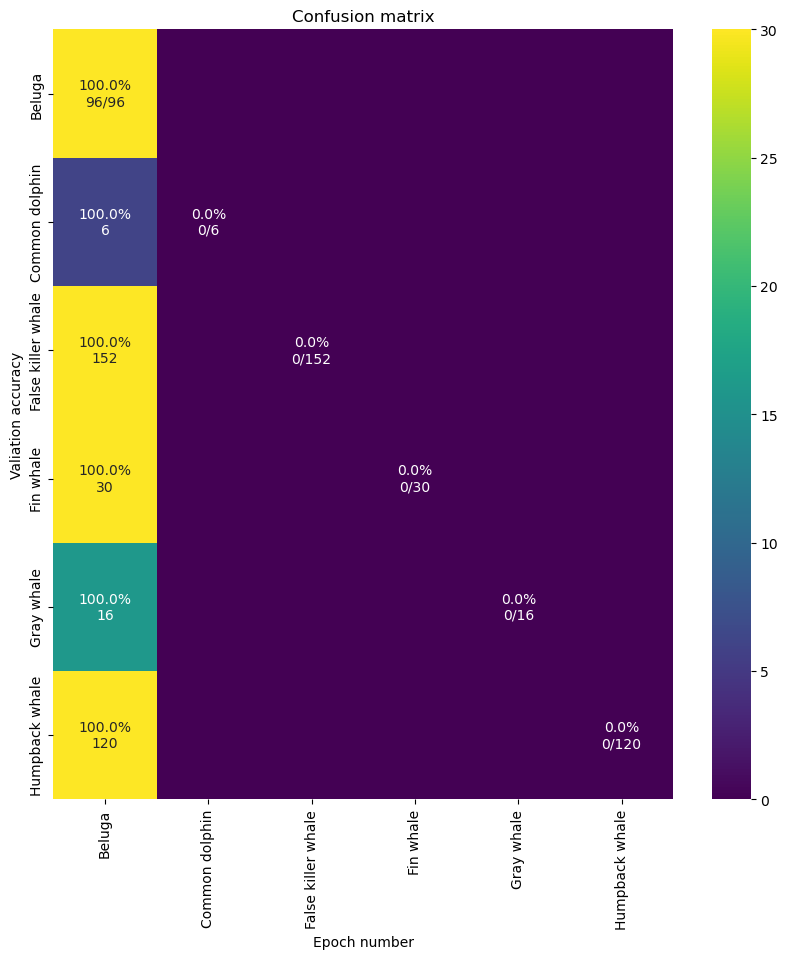

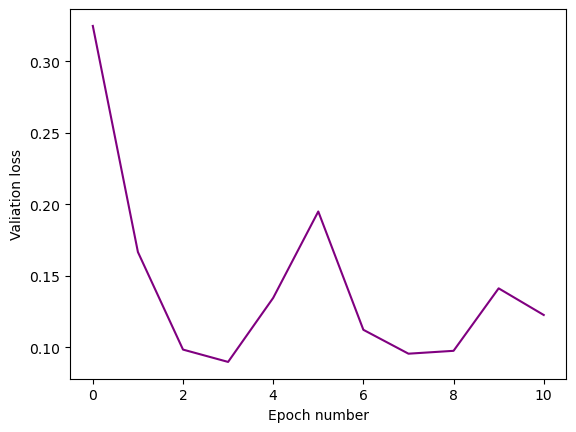

/tmp/ipykernel_1988929/1799700154.py:56: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)


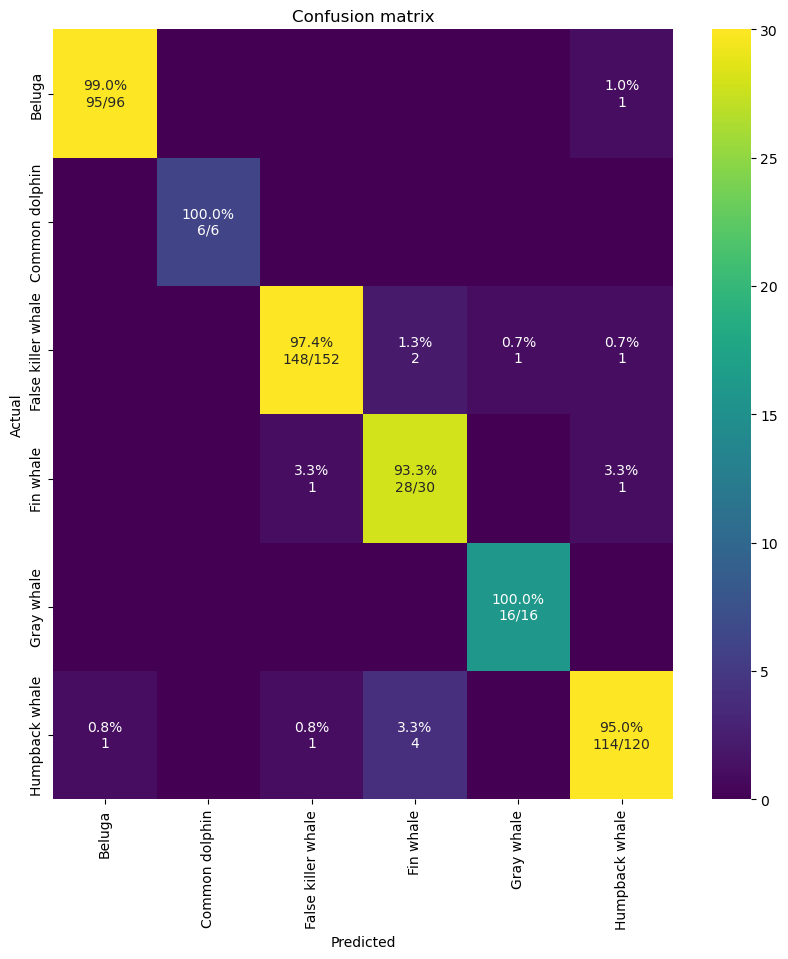

In [16]:
wandb.init(
    project="BGMP_HappyWhale",
    name="manasvil-university-of-oregon_mod3", ##update this with your name
    config={"learning rate":.005, # possibly update
        "architecture": "CNN",
        "dataset": "Species",
        "epochs": 11, "batch_size":32}  # possibly update
) 

# predict the test dataset
def predict(model, dataset):
    dataset_prediction = []
    dataset_groundtruth = []
    model = model
    with torch.no_grad():
        for x, y_true in dataset:
            inp = x[None]
            y_pred = model(inp)
            dataset_prediction.append(y_pred.argmax().cpu().numpy())
            dataset_groundtruth.append(y_true)
    
    return np.array(dataset_prediction), np.array(dataset_groundtruth)
            
    # create seaborn heatmap with required labels
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
    ax.set_title(title)

def cm_analysis(y_true, y_pred, title, figsize=(10,10)):
    """
    Generate matrix plot of confusion matrix with pretty annotations.
    The plot image is saved to disk.
    args: 
      y_true:    true label of the data, with shape (nsamples,)
      y_pred:    prediction of the data, with shape (nsamples,)
      filename:  filename of figure file to save
      labels:    string array, name the order of class labels in the confusion matrix.
                 use `clf.classes_` if using scikit-learn models.
                 with shape (nclass,).
      ymap:      dict: any -> string, length == nclass.
                 if not None, map the labels & ys to more understandable strings.
                 Caution: original y_true, y_pred and labels must align.
      figsize:   the size of the figure plotted.
    """
    labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale']
    cm = confusion_matrix(y_true, y_pred)
    cm_sum = np.sum(cm, axis=1, keepdims=True)
    cm_perc = cm / cm_sum.astype(float) * 100
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = cm_perc[i, j]
            if i == j:
                s = cm_sum[i]
                annot[i, j] = '%.1f%%\n%d/%d' % (p, c, s)
            elif c == 0:
                annot[i, j] = ''
            else:
                annot[i, j] = '%.1f%%\n%d' % (p, c)
    cm = pd.DataFrame(cm, index=labels, columns=labels)
    cm.index.name = 'Actual'
    cm.columns.name = 'Predicted'
    fig, ax = plt.subplots(figsize=figsize)
                              
    x_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for x-axis
    y_axis_labels = ['Beluga','Common dolphin', 'False killer whale', 'Fin whale', 'Gray whale','Humpback whale'] # labels for y-axis
    ax=sns.heatmap(cm, annot=annot, fmt='', vmax=30, xticklabels=x_axis_labels, yticklabels=y_axis_labels, cmap = "viridis")
    ax.set_title(title)

## This plot only contains the test set of data
## The test set of data has not been seen by the model yet
y_pred, y_true = predict(model, test_set)

print(y_true)
cm_analysis(y_true, y_pred, "Confusion matrix")    

batch=0
num_epochs = epochs
train_losses, train_acc_list, val_losses, val_acc_list = [], [], [],[]

for epoch in range(num_epochs):
    # Setting model to "training mode"
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    # For each batch of data within the loader
    for inputs, labels in train_loader:
        # Send our input images and their labels to the GPU
        inputs, labels = inputs.to(device), labels.to(device)
        # Zero the gradients
        optimizer.zero_grad()
        # Inputting our training images into the model
        # and Predicting the image classification label
        outputs = model(inputs)
        # Figuring out the loss from our predictions
        loss = criterion(outputs, labels)
        # Compute gradients (aka backward pass)
        loss.backward()
        # Update model parameters
        optimizer.step()

        # Adding the loss to our running sum
        # Loss is calculated for each batch within an epoch
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        batch+=1
        print(f'Epoch [{epoch+1}/{num_epochs}] | Batch #{batch} | Batch Accuracy {(correct/total)*100:.2f}%')


    # Getting metrics for our training pass 
    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_acc_list.append(train_acc)
    
    # Switching our model to "evaluation mode"
    model.eval()
    running_loss = 0.0
    correct, total = 0, 0
    # Disable gradient calculation b/c we are evalulating the model
    with torch.no_grad():
        # Load in batches of our validation data
        for inputs, labels in val_loader:
            # Send test images and labels to the GPU
            inputs, labels = inputs.to(device), labels.to(device)
            # Predict the image classification label
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            # Figuring out how many predicted labels = true labels
            correct += predicted.eq(labels).sum().item()

            # Figuring out the loss from our predictions
            loss = criterion(outputs, labels)
            # Adding the loss to our running sum
            # Loss is calculated for each batch within an epoch
            running_loss += loss.item() * inputs.size(0)
    # Getting our accuracy from our test data
    val_acc = 100. * correct / total
    val_acc_list.append(val_acc)
    # Getting the loss from our test data
    val_loss = running_loss / len(val_loader.dataset)
    val_losses.append(val_loss)
    
    print(f'Epoch [{epoch+1}/{num_epochs}] Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.2f}%')

    # log metrics to wandb
    wandb.log({"validation_accuracy": val_acc, "validation_loss": val_loss, "train_loss":train_loss})

wandb.finish()

plt.plot(range(epochs), val_acc_list, color = "magenta")
plt.xlabel("Epoch number")
plt.ylabel("Valiation accuracy")
plt.show()  

plt.plot(range(epochs), val_losses, color = "purple")
plt.xlabel("Epoch number")
plt.ylabel("Valiation loss")
plt.show()  

y_pred, y_true = predict(model, test_set)
cm_analysis(y_true, y_pred, "Confusion matrix")